# 15 — Heterogeneous side-car: DeepSeek-OCR + NVIDIA VLA + V-JEPA on one ewm-sm

Notebooks 08–14 proved the multi-LLM side-car. This notebook runs the same
apparatus with **three heterogeneous front-ends** — none of them an LLM
text generator:

| Front-end | Native env | What it emits | Capture |
| - | - | - | - |
| DeepSeek-OCR | `deepseek-ocr` | real vision-encoder token ids from a test image | `capture_ocr.jsonl` |
| NVIDIA Cosmos-Policy VLA | `ewm-vla` | real action chunk quantized by the frozen action codebook | `capture_vla.jsonl` |
| V-JEPA | `ewm-jepa` | ViT-L/16 target encodings quantized by the frozen cosine codebook | `capture_jepa.jsonl` |

The captures were produced **first**, each in its native env
(`captures/capture_*.py`), and written as the same standard `tid{n}` JSONL.
This notebook reads the three streams and runs ewm-sm exactly as before —
the lattice is encoding-agnostic: OCR token ids, action ids and patch ids
all land in the same HLLSet plane.

Frames are cumulative per front-end (the growing memory of each stream);
the VLA chunk is 16 actions long and is padded with its final state to the
common length `T = 24`.

In [1]:
import os, sys, json

import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import EwmScene, run_open_loop_from_streams

CAP = "/home/alexmy/.cache/ewm-hetero"
WORK = "/home/alexmy/.cache/ewm-hetero-union"
os.makedirs(WORK, exist_ok=True)

ewm = EwmScene()
print("ewm-scene:", ewm.bin)

ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene


In [2]:
def load_capture(name):
    frames = []
    with open(f"{CAP}/capture_{name}.jsonl") as fh:
        for line in fh:
            frames.append(json.loads(line))
    return [f["tokens"] for f in frames]

streams = {
    "ocr": load_capture("ocr"),
    "vla": load_capture("vla"),
    "jepa": load_capture("jepa"),
}

T = 24
# The VLA action chunk has 16 steps; pad with its final state (plateau).
streams["vla"] = streams["vla"] + [streams["vla"][-1]] * (T - len(streams["vla"]))
for name, fr in streams.items():
    print(f"{name:5s} frames={len(fr):2d}  tokens/frame={[len(x) for x in fr[:4]]} ... "
          f"unique_total={len({t for f in fr for t in f})}")

print()
for name in ("ocr", "vla", "jepa"):
    with open(f"{CAP}/capture_{name}.meta.json") as fh:
        meta = json.load(fh)
    print(name, "meta:", json.dumps(meta))

ocr   frames=24  tokens/frame=[1, 2, 3, 4] ... unique_total=14
vla   frames=24  tokens/frame=[3, 4, 5, 6] ... unique_total=4
jepa  frames=24  tokens/frame=[65, 130, 195, 260] ... unique_total=238

ocr meta: {"frontend": "deepseek-ocr", "mode": "vision", "model": "9f30c71f441d010e5429c532364a86705536c53a", "T": 24, "token_ids": 15, "vocab": 128000}
vla meta: {"frontend": "nvidia-vla-cosmos-policy", "task": "pick up the black bowl from table center and place it on the plate", "T": 16, "action_tids": 16, "action_codebook": 512, "proprio_codebook": 128, "value_codebook": 16}
jepa meta: {"frontend": "v-jepa", "model": "vitl16", "T": 24, "quantized_ids": 1568, "codebook": 4096, "latent_shape": [1, 1568, 1024]}


In [3]:
open_result = run_open_loop_from_streams(ewm, streams, WORK)
print("IICA (union == pyramid union):", open_result.same_union)
print("BSS trajectory:", open_result.M_ol.shape)
print("DFT period:", open_result.period)
print("frontends:", open_result.names)
print()
print("BSS sample (first 4 frames):")
for i in range(4):
    print(f"  t={i}:", np.round(open_result.M_ol[i], 4))

IICA (union == pyramid union): True
BSS trajectory: (24, 3)
DFT period: None
frontends: ['ocr', 'vla', 'jepa']

BSS sample (first 4 frames):
  t=0: [0.0976 0.75   0.1139]
  t=1: [0.1951 0.75   0.1981]
  t=2: [0.2683 1.     0.273 ]
  t=3: [0.3415 1.     0.3276]


## §1 — Pattern matrix `(Frontend, Ring)`

The m-dim BSS trajectory over the three front-end frames: how much of each
front-end's cumulative vocabulary is present in the union at each step.

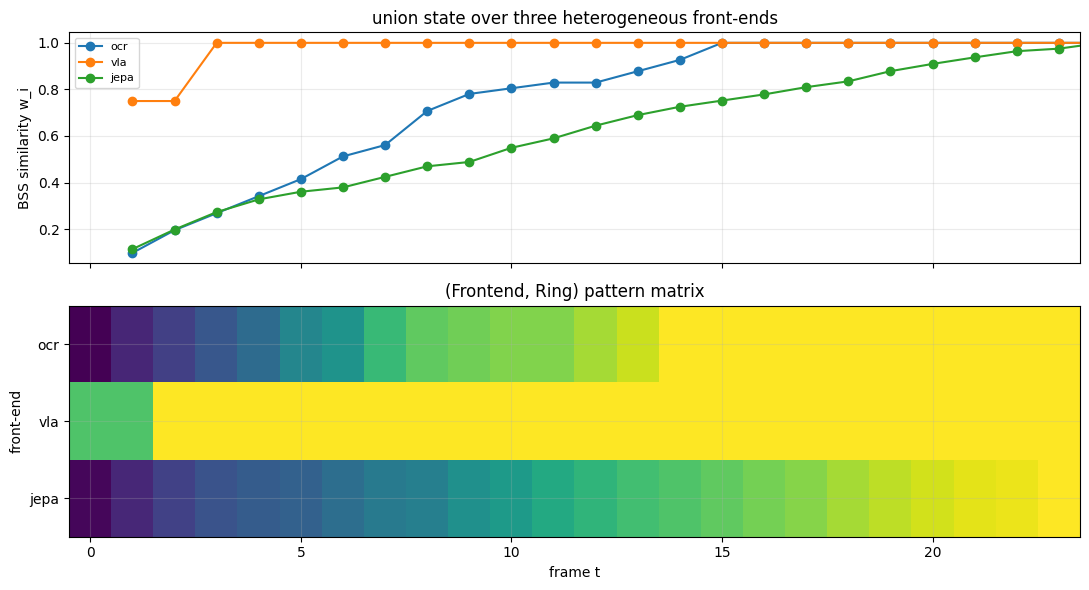

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

M = open_result.M_ol
t_axis = np.arange(1, M.shape[0] + 1)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for i, name in enumerate(open_result.names):
    axes[0].plot(t_axis, M[:, i], "o-", label=name)
axes[0].set_ylabel("BSS similarity w_i")
axes[0].set_title("union state over three heterogeneous front-ends")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].imshow(M.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[1].set_yticks(range(len(open_result.names)), open_result.names)
axes[1].set_xlabel("frame t")
axes[1].set_ylabel("front-end")
axes[1].set_title("(Frontend, Ring) pattern matrix")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/pattern_frontend_ring.png", dpi=110)
plt.show()

## §2 — Noether indicators: D / R / N of the union stream

The union of three modalities still has the D/R/N decomposition (the
apparatus does not know — or care — where the tids came from).

noether keys: ['dp', 'ind1', 'ind2', 'ind3', 'np', 'rp']


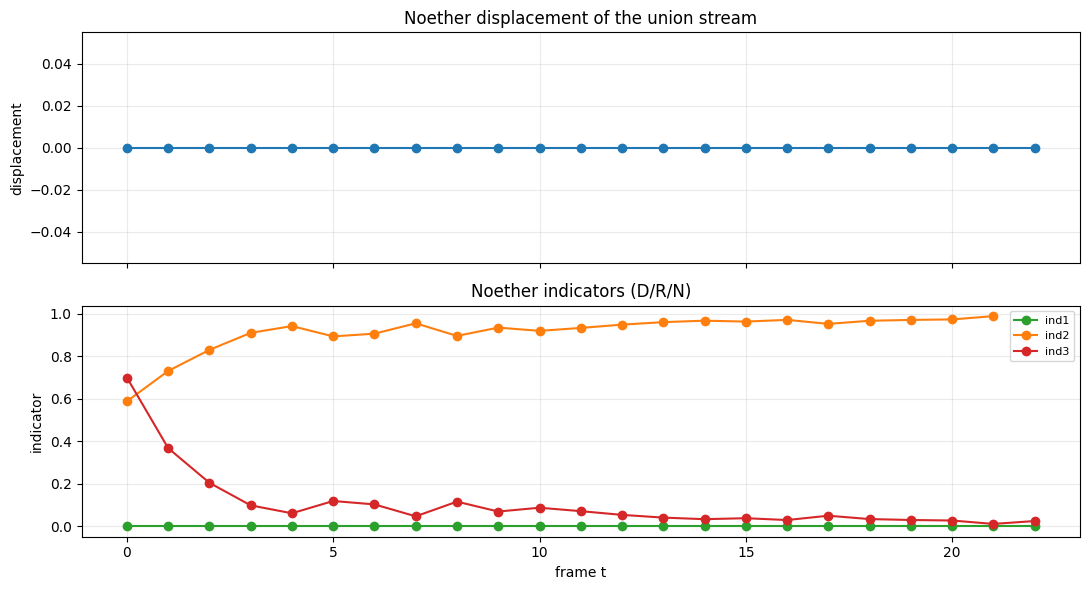

In [5]:
noether = ewm.noether(open_result.union_path)
print("noether keys:", list(noether.keys()))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(noether["dp"], "o-", color="tab:blue")
axes[0].set_ylabel("displacement")
axes[0].set_title("Noether displacement of the union stream")
axes[0].grid(alpha=0.25)

for key, color in [("ind1", "tab:green"), ("ind2", "tab:orange"), ("ind3", "tab:red")]:
    axes[1].plot(noether[key], "o-", label=key, color=color)
axes[1].set_ylabel("indicator")
axes[1].set_xlabel("frame t")
axes[1].set_title("Noether indicators (D/R/N)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/noether.png", dpi=110)
plt.show()

## §3 — Union state: keys and materialization

In [6]:
uni = ewm.ingest(open_result.union_path)
uf = uni["frames"]
print("frames:", len(uf))
print("union popcounts (first/last):", uf[0]["pop"], "->", uf[-1]["pop"])
print("first key:", uf[0]["key"][:56])
print("last  key:", uf[-1]["key"][:56])

mat = ewm.materialize(open_result.union_path)
last_ordered = mat["frames"][-1].get("ordered", [])
print()
print("materialized memory sample (last frame, restored order):")
print("  ", " ".join(last_ordered[:12]), "..." if len(last_ordered) > 12 else "")
print("  tokens restored:", len(last_ordered))

frames: 24
union popcounts (first/last): 80 -> 672
first key: h:7d70e448e6d82d7684ca6de4f785a827b840def1
last  key: h:18a706c594548acc1a5c6805fb2039e3ef0c51d4



materialized memory sample (last frame, restored order):
   tid0 tid10017 tid1019 tid1020 tid1029 tid10325 tid1038 tid1042 tid1083 tid1133 tid11347 tid1160 ...
  tokens restored: 254


## Summary

- The **same HLLSet lattice** ingested OCR token ids, VLA action ids and
  JEPA patch ids with zero changes to ewm-sm — the encoding-agnostic
  boundary (Principle 2: IICA morphisms) holds across three modalities.
- The pattern matrix `(Frontend, Ring)` and the Noether D/R/N indicators
  carry over unchanged from the multi-LLM notebooks; only the capture
  layer differs.
- This is the realistic scenario the multi-LLM POC was a warm-up for:
  the side-car now observes text, actions and world-model latents in one
  union state `S(t) = S_ocr(t) ∪ S_vla(t) ∪ S_jepa(t)`.

Next: close the loop across modalities — memory + curiosity over the
three-front-end union, and Jev (or the existing selectors) deciding which
front-end should act next. The FPGA "ready" flag stays recorded.